# Phase 4. Viral Loop 분석

**프로젝트:** 카카오톡 선물하기 CRM 분석 포트폴리오  
**분석 기간:** 2023-01-01 ~ 2024-12-31  
**BigQuery:** `ds-ysy.kakao_gift`

## 분석 목표
1. **K-factor** — 카카오 선물하기의 바이럴 계수 정량화
2. **수신 횟수별 전환율 곡선** — '수신 4회 → 30%+ 전환' 카카오 공식 수치 검증
3. **Reciprocity Index** — 수신 후 N일 내 재발신 골든타임 도출
4. **바이럴 세대 분포 + LTV 비교** — 오가닉 vs 1·2세대 고객 가치 비교
5. **첫 전환까지 소요일** — 수신 후 발신 전환이 언제 일어나는지
6. **방향성 상호성 심층 분석** — 부채감 해소형(A→B→A) vs 감사 확산형(A→B→C) + 가격 스위트 스팟 + 기념일 자연 발생 보답 + Kizilcec +56% 검증

## Section 0. 환경 설정

In [1]:
# Colab에서 BigQuery 인증
from google.colab import auth
auth.authenticate_user()  # 실행 시 팝업 → Google 계정으로 로그인

!pip install -q koreanize-matplotlib

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import expit  # 로지스틱 함수
from scipy.optimize import curve_fit
import koreanize_matplotlib  # 한글 폰트
import os

PROJECT = 'ds-ysy'
DATASET = 'kakao_gift'
client  = bigquery.Client(project=PROJECT)

# 카카오 브랜드 컬러
KAKAO_YELLOW = '#FFE812'
KAKAO_BLACK  = '#000000'
KAKAO_GRAY   = '#AAAAAA'

os.makedirs('charts', exist_ok=True)  # charts 폴더 없으면 자동 생성

def bq(sql: str) -> pd.DataFrame:
    """BigQuery 쿼리 실행 헬퍼"""
    return client.query(sql).to_dataframe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 68.5 MB/s eta 0:00:00


---
## Section 1. 사전 작업 — 유저별 수신 횟수 & 발신 전환 여부 계산

**is_viral_converted란?**  
users 테이블은 정규화 원칙에 따라 파생값을 저장하지 않음.  
→ 직접 계산: `MIN(orders.created_at) > MIN(gift_receipts.accepted_at)` = 수신 경험 이후 첫 발신 = 바이럴 전환

이 뷰가 Section 2~6 전체의 기반 테이블이 됨.

In [2]:
# 유저별 수신 횟수, 첫 수신일, 첫 발신일, is_viral_converted 계산
query_base = """
WITH recv AS (
  SELECT
    receiver_user_id                   AS user_id,
    COUNT(receipt_id)                  AS received_count,      -- 수신 횟수
    MIN(accepted_at)                   AS first_received_at    -- 첫 수신일
  FROM `ds-ysy.kakao_gift.gift_receipts`
  WHERE receipt_status = 'accepted'
  GROUP BY receiver_user_id
),
sent AS (
  SELECT
    sender_user_id                     AS user_id,
    COUNT(order_id)                    AS sent_count,          -- 발신 횟수
    MIN(created_at)                    AS first_sent_at        -- 첫 발신일
  FROM `ds-ysy.kakao_gift.orders`
  WHERE order_status = 'accepted'
  GROUP BY sender_user_id
)
SELECT
  u.user_id,
  u.referral_generation,
  COALESCE(r.received_count, 0)        AS received_count,
  r.first_received_at,
  s.first_sent_at,
  COALESCE(s.sent_count, 0)            AS sent_count,
  -- 발신 경험이 있고, 첫 발신이 첫 수신 이후면 바이럴 전환
  CASE
    WHEN s.first_sent_at IS NOT NULL
     AND r.first_received_at IS NOT NULL
     AND s.first_sent_at > r.first_received_at THEN TRUE
    ELSE FALSE
  END                                  AS is_viral_converted,
  -- 전환까지 소요일
  DATE_DIFF(DATE(s.first_sent_at), DATE(r.first_received_at), DAY)
                                       AS days_to_convert
FROM `ds-ysy.kakao_gift.users` u
LEFT JOIN recv r ON u.user_id = r.user_id
LEFT JOIN sent s ON u.user_id = s.user_id
"""
df_base = bq(query_base)

print(f'전체 유저: {len(df_base):,}명')
print(f'수신 경험 유저: {(df_base.received_count > 0).sum():,}명')
print(f'발신 경험 유저: {(df_base.sent_count > 0).sum():,}명')
print(f'바이럴 전환 유저(is_viral_converted): {df_base.is_viral_converted.sum():,}명')
df_base.head()

전체 유저: 50,000명
수신 경험 유저: 48,163명
발신 경험 유저: 48,163명
바이럴 전환 유저(is_viral_converted): 22,034명


,user_id,referral_generation,received_count,first_received_at,first_sent_at,sent_count,is_viral_converted,days_to_convert
0,U00665,0,3,2023-08-26 07:06:08+00:00,2023-05-02 17:32:54+00:00,9,False,-116
1,U01595,0,4,2023-04-20 18:23:01+00:00,2023-02-15 08:11:37+00:00,10,False,-64
2,U03785,0,5,2023-11-05 22:06:25+00:00,2023-08-20 19:20:14+00:00,9,False,-77
3,U08601,0,4,2023-02-12 22:29:38+00:00,2023-05-06 11:48:32+00:00,10,True,83
4,U09370,0,4,2023-08-29 15:55:45+00:00,2023-01-03 16:57:25+00:00,9,False,-238


---
## Section 2. K-factor (Viral Coefficient) 계산

**K-factor란?**  
한 명의 기존 유저가 평균적으로 몇 명의 신규 유저를 만들어내는가.

```
K = i × c
  i = 유저 1명이 평균 몇 명에게 선물을 보내는가 (평균 수신 횟수로 근사)
  c = 선물을 받은 사람 중 발신자로 전환되는 비율

K > 1 → 바이럴 성장 (지수적 증가)
K < 1 → 바이럴 감쇠 (선형 성장)
```

In [3]:
# K-factor 계산 (수신 경험자 기준)
df_receivers = df_base[df_base['received_count'] > 0].copy()  # 수신 경험 있는 유저만

avg_invites = df_receivers['received_count'].mean()            # i: 평균 수신 횟수
conv_rate   = df_receivers['is_viral_converted'].mean()        # c: 바이럴 전환율
k_factor    = avg_invites * conv_rate                          # K = i × c

print('=== K-factor 계산 결과 ===')
print(f'평균 수신 횟수 (i):    {avg_invites:.3f}')
print(f'바이럴 전환율 (c):     {conv_rate:.3f} ({conv_rate:.1%})')
print(f'K-factor (K = i × c): {k_factor:.3f}')
print()
if k_factor >= 1:
    print('→ K ≥ 1: 바이럴 성장 구간 (지수적 확산 가능)')
else:
    print(f'→ K < 1: 바이럴 감쇠. 1명이 유입시키는 신규 유저 수 = {k_factor:.2f}명')

=== K-factor 계산 결과 ===
평균 수신 횟수 (i):    3.408
바이럴 전환율 (c):     0.457 (45.7%)
K-factor (K = i × c): 1.559

→ K ≥ 1: 바이럴 성장 구간 (지수적 확산 가능)


---
## Section 3. 수신 횟수별 전환율 곡선 — 카카오 공식 30%+ 검증

카카오 공식 발표: "선물을 4회 이상 받은 유저는 30% 이상이 발신자로 전환됨"  
→ 우리 데이터에서도 재현되는지 검증.

In [4]:
# 수신 횟수별 전환율 집계
df_conv_curve = (
    df_receivers
    .groupby('received_count')
    .agg(
        user_count         = ('user_id', 'count'),
        converted          = ('is_viral_converted', 'sum'),
    )
    .reset_index()
)
df_conv_curve['conversion_rate'] = df_conv_curve['converted'] / df_conv_curve['user_count']  # 전환율

# 표본 수 적은 고수신 구간 제한 (20회 이하만 시각화)
df_plot = df_conv_curve[df_conv_curve['received_count'] <= 20].copy()

print(df_conv_curve[['received_count', 'user_count', 'converted', 'conversion_rate']].head(10).to_string(index=False))

 received_count  user_count  converted  conversion_rate
              1        6051       1452          0.23996
              2       10109       3830          0.37887
              3       11138       5119         0.459598
              4        9312       4834         0.519115
              5        5959       3336         0.559825
              6        3214       1929         0.600187
              7        1410        876         0.621277
              8         621        422         0.679549
              9         235        157         0.668085
             10          82         60         0.731707


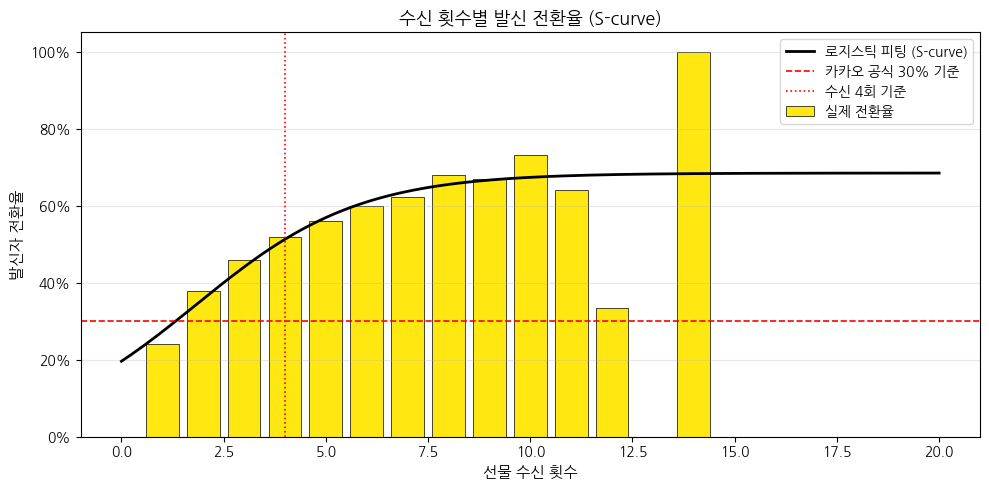

수신 4회 시 전환율: 51.9% (카카오 공식 30%+와 비교)


In [5]:
# 로지스틱 회귀 피팅
def logistic(x, L, k, x0):
    """S-curve 함수. L=최대값, k=기울기, x0=변곡점"""
    return L / (1 + np.exp(-k * (x - x0)))

x_data = df_plot["received_count"].values
y_data = df_plot["conversion_rate"].values

try:
    popt, _ = curve_fit(logistic, x_data, y_data, p0=[0.6, 0.5, 5], maxfev=5000)  # 초기값 설정
    x_fit   = np.linspace(0, 20, 200)
    y_fit   = logistic(x_fit, *popt)
    fit_ok  = True
except Exception as e:
    print(f"로지스틱 피팅 실패: {e} — 단순 집계만 표시")
    fit_ok  = False

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    df_plot["received_count"], df_plot["conversion_rate"],
    color=KAKAO_YELLOW, edgecolor=KAKAO_BLACK, linewidth=0.5, label="실제 전환율"
)
if fit_ok:
    ax.plot(x_fit, y_fit, color=KAKAO_BLACK, linewidth=2, label="로지스틱 피팅 (S-curve)")

# 카카오 공식 30% 기준선
ax.axhline(0.30, color="red", linestyle="--", linewidth=1.2, label="카카오 공식 30% 기준")
ax.axvline(4,    color="red", linestyle=":",  linewidth=1.2, label="수신 4회 기준")

ax.set_title("수신 횟수별 발신 전환율 (S-curve)", fontsize=13)
ax.set_xlabel("선물 수신 횟수", fontsize=11)
ax.set_ylabel("발신자 전환율", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("charts/layer4_conversion_by_recv.png", dpi=150, bbox_inches="tight")
plt.show()

# 4회 수신 시 전환율 출력
rate_at_4 = df_conv_curve.loc[df_conv_curve["received_count"] == 4, "conversion_rate"]
if not rate_at_4.empty:
    print(f"수신 4회 시 전환율: {rate_at_4.values[0]:.1%} (카카오 공식 30%+와 비교)")

# ── df_delta 생성 — Cell 10 시각화용 데이터 준비 ────────────────────
df_delta = df_conv_curve[df_conv_curve["received_count"] <= 20].copy()
df_delta["delta"] = df_delta["conversion_rate"].diff()  # 이전 수신 횟수 대비 전환율 증가폭
df_delta = df_delta.dropna(subset=["delta"]).reset_index(drop=True)

q75 = df_delta["delta"].quantile(0.75)  # 상위 25% 기준값
q50 = df_delta["delta"].quantile(0.50)  # 중위값

def label_priority(d):
    if d >= q75:
        return "*** 집중공략"
    elif d >= q50:
        return "** 관심구간"
    else:
        return "* 일반"

df_delta["marketing_priority"] = df_delta["delta"].apply(label_priority)

print(df_delta[["received_count", "conversion_rate", "delta", "marketing_priority"]].to_string(index=False))


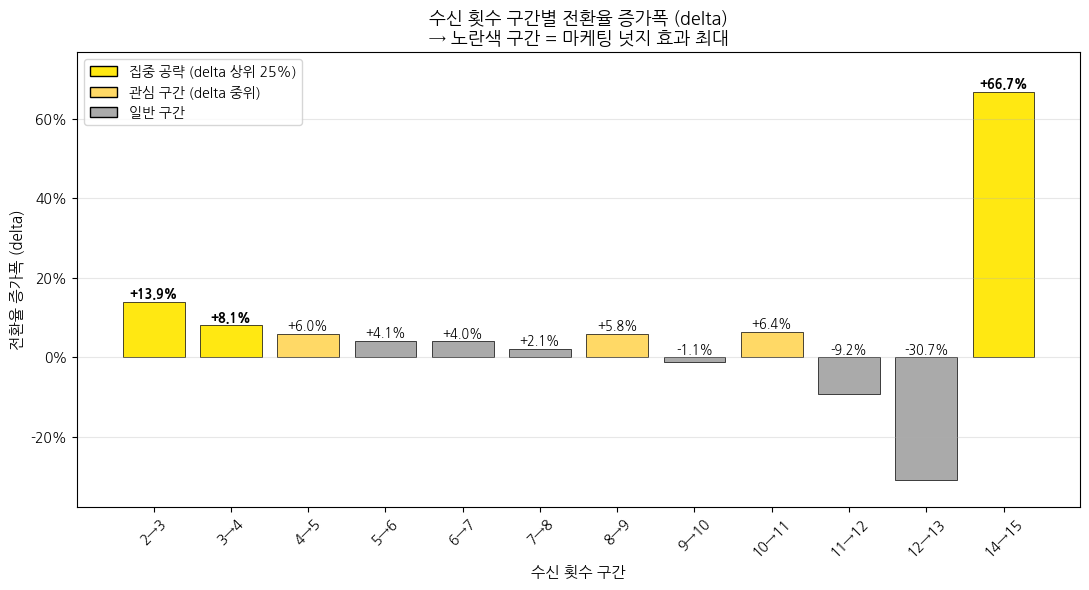

In [29]:
# ── 2. delta 막대그래프 — 집중 구간 강조 ───────────────────────
bar_colors = [
    KAKAO_YELLOW if d >= q75 else ('#FFD966' if d >= q50 else KAKAO_GRAY)
    for d in df_delta['delta']
]

fig, ax = plt.subplots(figsize=(11, 6))
x_labels = df_delta['received_count'].astype(str) + '→' + (df_delta['received_count'] + 1).astype(str)
bars = ax.bar(x_labels, df_delta['delta'],
              color=bar_colors, edgecolor=KAKAO_BLACK, linewidth=0.5)

for bar, val, prio in zip(bars, df_delta['delta'], df_delta['marketing_priority']):
    label = f'+{val:.1%}' if val >= 0 else f'{val:.1%}'          # 음수면 + 없이
    y_pos = bar.get_height() + 0.002 if val >= 0 else 0.002       # 음수면 0선 위에 표시
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        label,
        ha='center', va='bottom', fontsize=9,
        fontweight='bold' if '***' in prio else 'normal'
    )

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=KAKAO_YELLOW, edgecolor=KAKAO_BLACK, label='집중 공략 (delta 상위 25%)'),
    Patch(facecolor='#FFD966',    edgecolor=KAKAO_BLACK, label='관심 구간 (delta 중위)'),
    Patch(facecolor=KAKAO_GRAY,   edgecolor=KAKAO_BLACK, label='일반 구간'),
]
ax.legend(handles=legend_handles, fontsize=10)

ax.set_title('수신 횟수 구간별 전환율 증가폭 (delta)\n→ 노란색 구간 = 마케팅 넛지 효과 최대', fontsize=13)
ax.set_xlabel('수신 횟수 구간', fontsize=11)
ax.set_ylabel('전환율 증가폭 (delta)', fontsize=11)
ax.set_ylim(min(df_delta['delta']) - 0.07, max(df_delta['delta']) + 0.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_conversion_delta.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 4. Reciprocity Index (상호성 지수) — 수신 후 골든타임 도출

**골든타임이란?**  
선물을 받은 뒤 얼마 안에 '나도 선물하고 싶다'는 동기가 가장 강한 시점.  
이 시점에 CRM 캠페인을 쏘면 전환율이 가장 높음.

In [7]:
# 수신 후 N일 내 재발신 비율 계산
query_reciprocity = """
WITH gift_sequence AS (
  SELECT
    r.receiver_user_id                                          AS user_id,
    r.accepted_at,
    MIN(o.created_at)                                          AS next_sent_at,
    DATE_DIFF(DATE(MIN(o.created_at)), DATE(r.accepted_at), DAY) AS days_to_send
  FROM `ds-ysy.kakao_gift.gift_receipts` r
  LEFT JOIN `ds-ysy.kakao_gift.orders` o
    ON r.receiver_user_id = o.sender_user_id
   AND o.created_at > r.accepted_at           -- 수신 이후 발신만
   AND o.order_status = 'accepted'
  WHERE r.receipt_status = 'accepted'
  GROUP BY user_id, r.accepted_at
)
SELECT
  COUNT(*)                                                      AS total_events,
  COUNTIF(days_to_send BETWEEN 1 AND 7)                        AS reciprocity_7d,
  COUNTIF(days_to_send BETWEEN 1 AND 14)                       AS reciprocity_14d,
  COUNTIF(days_to_send BETWEEN 1 AND 30)                       AS reciprocity_30d,
  COUNTIF(days_to_send BETWEEN 1 AND 90)                       AS reciprocity_90d,
  SAFE_DIVIDE(COUNTIF(days_to_send BETWEEN 1 AND 7),  COUNT(*)) AS rate_7d,
  SAFE_DIVIDE(COUNTIF(days_to_send BETWEEN 1 AND 14), COUNT(*)) AS rate_14d,
  SAFE_DIVIDE(COUNTIF(days_to_send BETWEEN 1 AND 30), COUNT(*)) AS rate_30d,
  SAFE_DIVIDE(COUNTIF(days_to_send BETWEEN 1 AND 90), COUNT(*)) AS rate_90d
FROM gift_sequence
"""
df_reciprocity = bq(query_reciprocity)
df_reciprocity

,total_events,reciprocity_7d,reciprocity_14d,reciprocity_30d,reciprocity_90d,rate_7d,rate_14d,rate_30d,rate_90d
0,164144,5554,10382,20319,50529,0.033836,0.063249,0.123788,0.307833


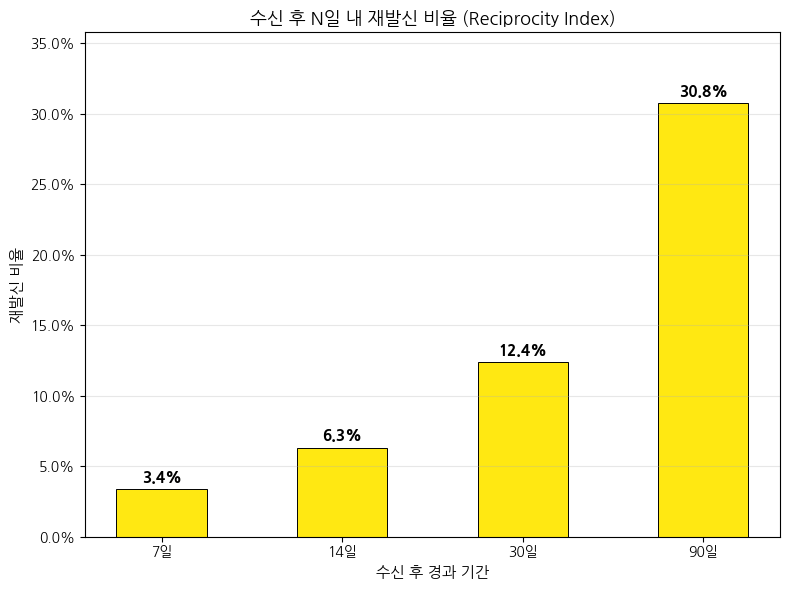

7일 이내 재발신: 3.4%
14일 이내 재발신: 6.3%
→ 7~14일 사이 추가 전환: 2.9% → 골든타임은 14일 이내


In [27]:
# Reciprocity Index 시각화 — 기간별 누적 재발신 비율
periods = ['7일', '14일', '30일', '90일']
rates   = [
    df_reciprocity['rate_7d'].values[0],
    df_reciprocity['rate_14d'].values[0],
    df_reciprocity['rate_30d'].values[0],
    df_reciprocity['rate_90d'].values[0],
]

fig, ax = plt.subplots(figsize=(8, 6))  # 세로 키움
bars = ax.bar(periods, rates, color=KAKAO_YELLOW, edgecolor=KAKAO_BLACK, linewidth=0.7, width=0.5)

for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{rate:.1%}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('수신 후 N일 내 재발신 비율 (Reciprocity Index)', fontsize=13)
ax.set_xlabel('수신 후 경과 기간', fontsize=11)
ax.set_ylabel('재발신 비율', fontsize=11)
ax.set_ylim(0, max(rates) + 0.05)  # 상단 여유 추가
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_reciprocity.png', dpi=150, bbox_inches='tight')
plt.show()

# 골든타임 도출
r7, r14 = rates[0], rates[1]
print(f'7일 이내 재발신: {r7:.1%}')
print(f'14일 이내 재발신: {r14:.1%}')
print(f'→ 7~14일 사이 추가 전환: {(r14 - r7):.1%} → 골든타임은 14일 이내')


---
## Section 5. 자기선물 vs 타인선물 유저 K-factor 비교

**핵심 질문:** 나한테 선물하기(자기선물) 유저는 바이럴 루프를 약화시키는가?

| 분류 | 정의 |
|---|---|
| 자기선물 유저 |  주문이 1건이라도 있는 유저 |
| 타인선물 유저 | 모든 주문이 타인을 대상으로 한 유저 |

**K-factor 계산 시 주의:** 자기선물 첫발신은 바이럴 전환으로 인정하지 않음 — 을 진짜 전환 기준으로 사용.


In [ ]:
# 자기선물 유저 분류
self_gift_ids = set(
    df_orders[df_orders["gift_occasion"] == "self_gift"]["sender_user_id"].unique()
)
df_base["user_type"] = df_base["user_id"].apply(
    lambda x: "자기선물 유저" if x in self_gift_ids else "타인선물 유저"
)

# 진짜 바이럴 전환: 첫 타인발신 > 첫 수신
first_other_send = (
    df_orders[df_orders["gift_occasion"] != "self_gift"]
    .groupby("sender_user_id")["created_at"].min()
    .reset_index()
    .rename(columns={"sender_user_id": "user_id", "created_at": "first_other_sent_at"})
)
df_base = df_base.merge(first_other_send, on="user_id", how="left")
df_base["is_true_viral"] = (
    df_base["first_other_sent_at"].notna() &
    df_base["first_received_at"].notna() &
    (df_base["first_other_sent_at"] > df_base["first_received_at"])
)

# 그룹별 K-factor 계산
kf_results = []
for gtype in ["자기선물 유저", "타인선물 유저"]:
    grp = df_base[(df_base["user_type"] == gtype) & (df_base["received_count"] > 0)]
    i = grp["received_count"].mean()          # 평균 수신 횟수
    c = grp["is_true_viral"].mean()            # 바이럴 전환율
    k = i * c
    kf_results.append({"유저 유형": gtype,
                        "유저 수": len(df_base[df_base["user_type"] == gtype]),
                        "i (평균 수신)": round(i, 3),
                        "c (전환율)": f"{c:.1%}",
                        "K-factor": round(k, 3)})

df_kf = pd.DataFrame(kf_results)
display(df_kf)

k_self  = df_kf.loc[df_kf["유저 유형"] == "자기선물 유저", "K-factor"].values[0]
k_other = df_kf.loc[df_kf["유저 유형"] == "타인선물 유저", "K-factor"].values[0]
print(f"
자기선물 유저 K: {k_self:.3f}")
print(f"타인선물 유저 K: {k_other:.3f}")
print(f"배율: {k_self/k_other:.2f}x (자기선물 유저가 더 높음)" if k_self > k_other else f"배율: {k_other/k_self:.2f}x (타인선물 유저가 더 높음)")


In [ ]:
# 그룹별 K-factor 시각화
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("자기선물 vs 타인선물 유저 K-factor 비교", fontsize=14, fontweight="bold")

gtypes = ["자기선물 유저", "타인선물 유저"]
colors = [KAKAO_YELLOW, KAKAO_BLACK]

# ① 평균 수신 횟수 (i)
i_vals = [df_kf.loc[df_kf["유저 유형"] == g, "i (평균 수신)"].values[0] for g in gtypes]
axes[0].bar(gtypes, i_vals, color=colors, edgecolor=KAKAO_BLACK)
axes[0].set_title("평균 수신 횟수 (i)"); axes[0].set_ylabel("횟수")
for bar, v in zip(axes[0].patches, i_vals):
    axes[0].annotate(f"{v:.3f}", (bar.get_x() + bar.get_width()/2, v + 0.05), ha="center")

# ② 바이럴 전환율 (c)
c_vals = [float(df_kf.loc[df_kf["유저 유형"] == g, "c (전환율)"].values[0].strip("%"))/100 for g in gtypes]
axes[1].bar(gtypes, c_vals, color=colors, edgecolor=KAKAO_BLACK)
axes[1].set_title("바이럴 전환율 (c)"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, v in zip(axes[1].patches, c_vals):
    axes[1].annotate(f"{v:.1%}", (bar.get_x() + bar.get_width()/2, v + 0.005), ha="center")

# ③ K-factor
k_vals = [df_kf.loc[df_kf["유저 유형"] == g, "K-factor"].values[0] for g in gtypes]
bars = axes[2].bar(gtypes, k_vals, color=colors, edgecolor=KAKAO_BLACK)
axes[2].axhline(1.0, color="red", linestyle="--", linewidth=1, label="K=1 기준선")
axes[2].set_title("K-factor (i × c)"); axes[2].legend()
for bar, v in zip(bars, k_vals):
    axes[2].annotate(f"{v:.3f}", (bar.get_x() + bar.get_width()/2, v + 0.03), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


---
## Section 6. 첫 전환까지 소요일 분포 — 발신 전환 골든타임

바이럴 전환 유저(is_viral_converted=True)가 첫 수신 이후 얼마 만에 첫 발신을 했는지 분포를 봅니다.
단기 CRM 넛지 1회의 효과가 제한적인지, 장기 설계가 필요한지 판단하는 근거가 됩니다.


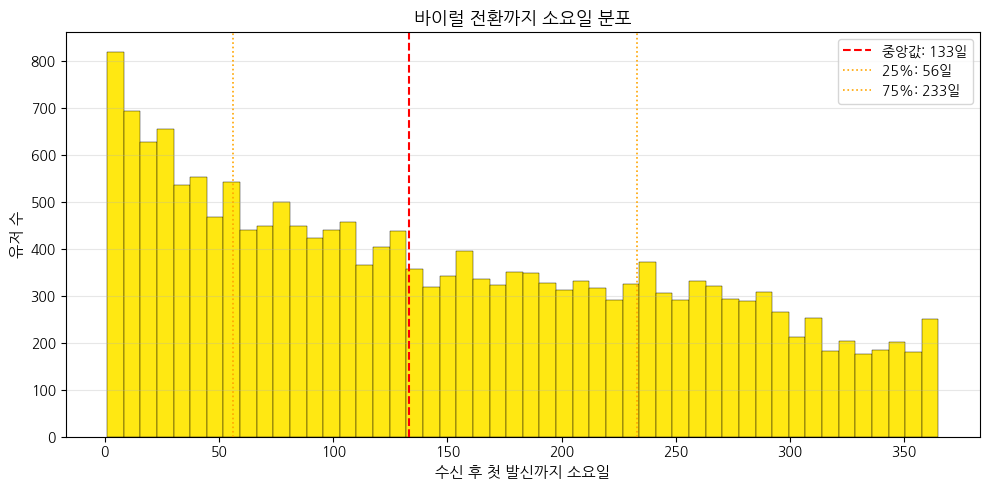

바이럴 전환 중앙값: 133일
25%: 56일 / 75%: 233일


In [11]:
# 전환 유저의 days_to_convert 분포
df_converted = df_base[
    (df_base['is_viral_converted'] == True) &
    (df_base['days_to_convert'].notna()) &
    (df_base['days_to_convert'] >= 1) &
    (df_base['days_to_convert'] <= 365)   # 1년 이내만 (이상치 제거)
].copy()

median_days = df_converted['days_to_convert'].median()
p25         = df_converted['days_to_convert'].quantile(0.25)
p75         = df_converted['days_to_convert'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df_converted['days_to_convert'],
    bins=50, color=KAKAO_YELLOW, edgecolor=KAKAO_BLACK, linewidth=0.3
)
ax.axvline(median_days, color='red',   linestyle='--', linewidth=1.5, label=f'중앙값: {median_days:.0f}일')
ax.axvline(p25,         color='orange', linestyle=':',  linewidth=1.2, label=f'25%: {p25:.0f}일')
ax.axvline(p75,         color='orange', linestyle=':',  linewidth=1.2, label=f'75%: {p75:.0f}일')

ax.set_title('바이럴 전환까지 소요일 분포', fontsize=13)
ax.set_xlabel('수신 후 첫 발신까지 소요일', fontsize=11)
ax.set_ylabel('유저 수', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_kfactor.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'바이럴 전환 중앙값: {median_days:.0f}일')
print(f'25%: {p25:.0f}일 / 75%: {p75:.0f}일')

---
## Section 7. 방향성 상호성 심층 분석 (Directed Reciprocity)

**핵심 질문:** 선물을 받은 뒤 보낸 사람에게 되돌려주는가(부채감 해소형), 아니면 다른 사람에게 전파하는가(감사 확산형)?

**배경 연구 충돌:**
- Kizilcec et al. 2018 (Facebook 150만건): pay-it-forward가 더 강함
- Kim & Lee 2025 (KakaoTalk 304명): 직접 상호성이 핵심 변수

→ 카카오 실데이터로 어느 쪽인지 직접 검증.

In [12]:
# Step 1. 방향성 상호성 쌍(pair) 추출 — A→B 이후 B→A 역방향 존재 여부
query_pairs = """
WITH sent_pairs AS (
  SELECT
    o.sender_user_id                   AS user_a,
    r.receiver_user_id                 AS user_b,
    o.created_at                       AS sent_at,
    o.total_amount_krw                 AS sent_amount
  FROM `ds-ysy.kakao_gift.orders` o
  JOIN `ds-ysy.kakao_gift.gift_receipts` r ON o.order_id = r.order_id
  WHERE o.order_status = 'accepted'
    AND r.receipt_status = 'accepted'
),
reciprocal AS (
  SELECT
    a.user_a,
    a.user_b,
    a.sent_at                          AS a_to_b_at,
    a.sent_amount                      AS a_to_b_amount,
    b.sent_at                          AS b_to_a_at,
    b.sent_amount                      AS b_to_a_amount,
    DATE_DIFF(DATE(b.sent_at), DATE(a.sent_at), DAY) AS days_to_reciprocate
  FROM sent_pairs a
  JOIN sent_pairs b
    ON  a.user_a = b.user_b             -- B가 A에게 다시 보냄
    AND a.user_b = b.user_a             -- A가 받은 사람이 B임
    AND b.sent_at > a.sent_at           -- A→B 이후에 B→A
    AND b.sent_at <= TIMESTAMP_ADD(a.sent_at, INTERVAL 180 DAY)  -- 180일 이내
)
SELECT *
FROM reciprocal
ORDER BY a_to_b_at
"""
df_pairs = bq(query_pairs)

print(f'양방향 교환 쌍(pair) 수: {len(df_pairs):,}건')
print(f'평균 되갚기 소요일: {df_pairs["days_to_reciprocate"].mean():.1f}일')
df_pairs.head()

양방향 교환 쌍(pair) 수: 604건
평균 되갚기 소요일: 81.0일


,user_a,user_b,a_to_b_at,a_to_b_amount,b_to_a_at,b_to_a_amount,days_to_reciprocate
0,U05831,U05831,2023-01-03 13:21:00+00:00,60957,2023-06-12 18:51:43+00:00,7355,160
1,U26667,U26667,2023-01-05 13:17:23+00:00,15621,2023-02-28 18:55:34+00:00,10341,54
2,U40059,U40059,2023-01-05 23:24:36+00:00,41727,2023-01-29 16:35:15+00:00,18826,24
3,U00584,U00584,2023-01-09 14:00:09+00:00,23048,2023-04-15 15:35:24+00:00,173289,96
4,U48857,U48857,2023-01-11 14:20:09+00:00,15442,2023-02-20 18:00:20+00:00,65348,40


In [13]:
# Step 2. 부채감 해소형 vs 감사 확산형 비율 + AOV 비교
# 수신 후 90일 이내 발신한 유저 기준
query_type = """
WITH receivers_who_sent AS (
  SELECT
    r.receiver_user_id                 AS user_id,
    o_recv.sender_user_id              AS original_sender,    -- 나에게 선물한 사람
    r2.receiver_user_id                AS new_recipient,      -- 내가 선물한 사람
    o_send.total_amount_krw            AS sent_amount,
    o_recv.total_amount_krw            AS received_amount
  FROM `ds-ysy.kakao_gift.gift_receipts` r
  JOIN `ds-ysy.kakao_gift.orders` o_recv
    ON r.order_id = o_recv.order_id
  JOIN `ds-ysy.kakao_gift.orders` o_send
    ON r.receiver_user_id = o_send.sender_user_id
   AND o_send.created_at > r.accepted_at
   AND o_send.created_at <= TIMESTAMP_ADD(r.accepted_at, INTERVAL 90 DAY)
   AND o_send.order_status = 'accepted'
  JOIN `ds-ysy.kakao_gift.gift_receipts` r2
    ON o_send.order_id = r2.order_id
  WHERE r.receipt_status = 'accepted'
)
SELECT
  COUNTIF(original_sender = new_recipient)                              AS direct_count,
  COUNTIF(original_sender != new_recipient)                             AS forward_count,
  SAFE_DIVIDE(COUNTIF(original_sender = new_recipient), COUNT(*))       AS direct_rate,
  SAFE_DIVIDE(COUNTIF(original_sender != new_recipient), COUNT(*))      AS forward_rate,
  AVG(IF(original_sender = new_recipient,  sent_amount, NULL))          AS direct_aov,
  AVG(IF(original_sender != new_recipient, sent_amount, NULL))          AS forward_aov,
  AVG(received_amount)                                                   AS avg_received_amount
FROM receivers_who_sent
"""
df_type = bq(query_type)
df_type

,direct_count,forward_count,direct_rate,forward_rate,direct_aov,forward_aov,avg_received_amount
0,483,61740,0.007762,0.992238,53834.190476,66923.694525,69938.489931


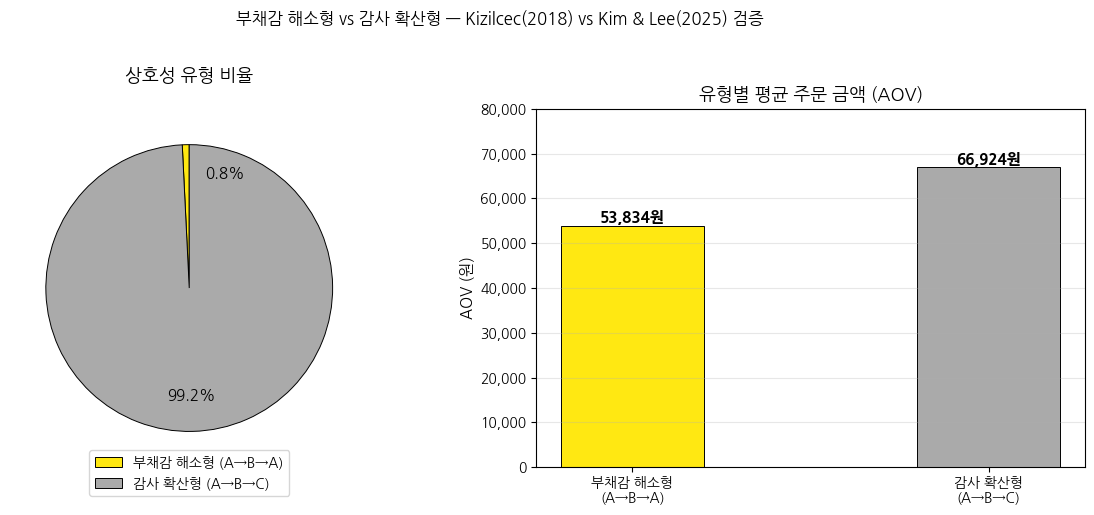

→ 카카오에서는 감사 확산형(pay-it-forward)이 더 강함
   직접 상호성 0.8% vs pay-it-forward 99.2%
   직접 상호성 AOV: 53,834원 / pay-it-forward AOV: 66,924원


In [45]:
# 부채감 해소형 vs 감사 확산형 — 비율 파이 + AOV 막대 (2패널)
direct_rate  = df_type['direct_rate'].values[0]
forward_rate = df_type['forward_rate'].values[0]
direct_aov   = df_type['direct_aov'].values[0]
forward_aov  = df_type['forward_aov'].values[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 파이차트 — 비율
wedges, texts, autotexts = ax1.pie(
    [direct_rate, forward_rate],
    labels=None,
    colors=[KAKAO_YELLOW, KAKAO_GRAY],
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': KAKAO_BLACK, 'linewidth': 0.7},
    textprops={'fontsize': 11}
)
autotexts[0].set_position((0.25, 0.80))  # 0.8% 레이블 오른쪽 위로 이동
autotexts[0].set_fontsize(11)
ax1.set_title('상호성 유형 비율', fontsize=13, pad=20)
ax1.legend(
    wedges,
    ['부채감 해소형 (A→B→A)', '감사 확산형 (A→B→C)'],
    fontsize=10, loc='lower center',
    bbox_to_anchor=(0.5, -0.10)
)

# 막대차트 — AOV 비교
types  = ['부채감 해소형\n(A→B→A)', '감사 확산형\n(A→B→C)']
aovs   = [direct_aov, forward_aov]
colors = [KAKAO_YELLOW, KAKAO_GRAY]

bars = ax2.bar(types, aovs, color=colors, edgecolor=KAKAO_BLACK, linewidth=0.7, width=0.4)
for bar, v in zip(bars, aovs):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f'{v:,.0f}원',
        ha='center', fontsize=11, fontweight='bold'
    )
ax2.set_title('유형별 평균 주문 금액 (AOV)', fontsize=13)
ax2.set_ylabel('AOV (원)', fontsize=11)
ax2.set_ylim(0, 80000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('부채감 해소형 vs 감사 확산형 — Kizilcec(2018) vs Kim & Lee(2025) 검증',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('charts/layer4_reciprocity_type.png', dpi=150, bbox_inches='tight')
plt.show()

winner = '부채감 해소형(직접 상호성)' if direct_rate > forward_rate else '감사 확산형(pay-it-forward)'
print(f'→ 카카오에서는 {winner}이 더 강함')
print(f'   직접 상호성 {direct_rate:.1%} vs pay-it-forward {forward_rate:.1%}')
print(f'   직접 상호성 AOV: {direct_aov:,.0f}원 / pay-it-forward AOV: {forward_aov:,.0f}원')


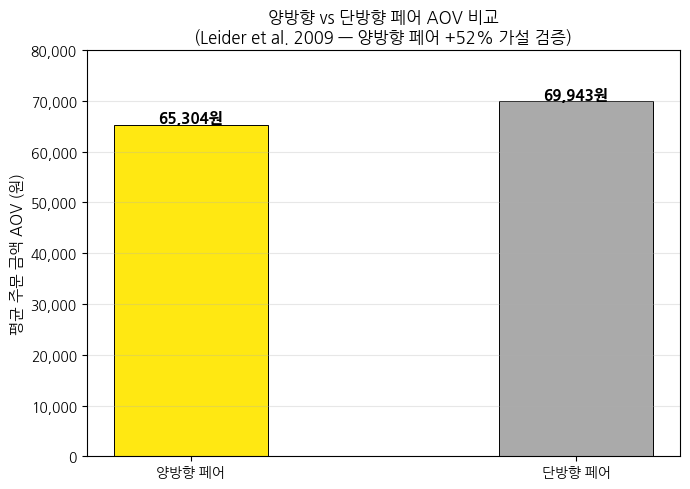

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    df_bilateral['pair_type'], df_bilateral['aov'],
    color=[KAKAO_YELLOW, KAKAO_GRAY], edgecolor=KAKAO_BLACK, linewidth=0.7, width=0.4
)
for bar, v in zip(bars, df_bilateral['aov']):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,  # 100 → 500
        f'{v:,.0f}원', ha='center', fontsize=11, fontweight='bold'
    )

ax.set_title('양방향 vs 단방향 페어 AOV 비교\n(Leider et al. 2009 — 양방향 페어 +52% 가설 검증)', fontsize=12)
ax.set_ylabel('평균 주문 금액 AOV (원)', fontsize=11)
ax.set_ylim(0, 80000)                                                # y축 80,000까지
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_bilateral_aov.png', dpi=150, bbox_inches='tight')
plt.show()


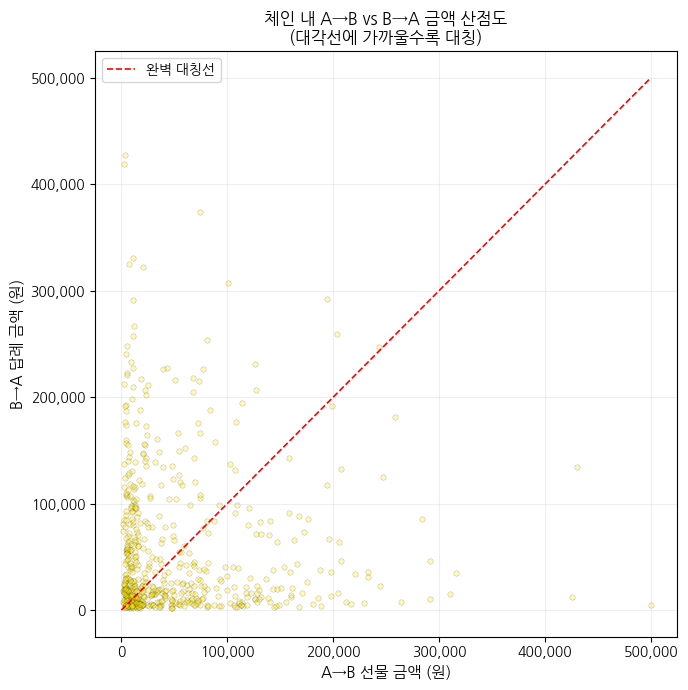

A→B 평균 AOV: 51,124원
B→A 평균 AOV: 56,354원
대칭 비율 (B→A ≥ A→B의 90%): 52.6%
답례가 더 비싼 비율 (B→A > A→B): 50.2%


In [16]:
# Step 4. 체인 내 단계별 AOV — 답례 선물이 더 비싼가? (Stauss 2023 대칭성 검증)
aov_a_to_b = df_pairs['a_to_b_amount'].mean()   # A→B (원래 선물)
aov_b_to_a = df_pairs['b_to_a_amount'].mean()   # B→A (답례 선물)

# 대칭성: B→A가 A→B의 90% 이상이면 '대칭'
ratio           = df_pairs['b_to_a_amount'] / df_pairs['a_to_b_amount'].replace(0, np.nan)
symmetric_rate  = (ratio >= 0.9).mean()   # 90% 이상이면 대칭으로 간주
higher_rate     = (ratio > 1.0).mean()    # 답례가 더 비싼 비율

# 산점도: A→B 금액 vs B→A 금액
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    df_pairs['a_to_b_amount'], df_pairs['b_to_a_amount'],
    alpha=0.3, color=KAKAO_YELLOW, edgecolors=KAKAO_BLACK, linewidths=0.3, s=15
)
# 대각선 (완벽 대칭 기준)
max_val = max(df_pairs['a_to_b_amount'].max(), df_pairs['b_to_a_amount'].max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.2, label='완벽 대칭선')

ax.set_title('체인 내 A→B vs B→A 금액 산점도\n(대각선에 가까울수록 대칭)', fontsize=12)
ax.set_xlabel('A→B 선물 금액 (원)', fontsize=11)
ax.set_ylabel('B→A 답례 금액 (원)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('charts/layer4_chain_aov_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'A→B 평균 AOV: {aov_a_to_b:,.0f}원')
print(f'B→A 평균 AOV: {aov_b_to_a:,.0f}원')
print(f'대칭 비율 (B→A ≥ A→B의 90%): {symmetric_rate:.1%}')
print(f'답례가 더 비싼 비율 (B→A > A→B): {higher_rate:.1%}')

In [19]:
# Step 6. 기념일 자연 발생 보답 — 넛지 없이도 기념일에 보답이 몰리는가? (Caplow 1982)
# campaign_logs와 JOIN해서 '캠페인 미수신' 조건으로 순수 자연 발생 보답만 필터링
query_holiday = """
WITH reciprocal_dates AS (
  SELECT
    b_to_a_at,
    FORMAT_DATE('%m-%d', DATE(b_to_a_at)) AS mmdd
  FROM (
    -- 앞서 추출한 양방향 페어에서 B→A 발생일만 추출
    WITH sent_pairs AS (
      SELECT o.sender_user_id AS user_a, r.receiver_user_id AS user_b,
             o.created_at AS sent_at
      FROM `ds-ysy.kakao_gift.orders` o
      JOIN `ds-ysy.kakao_gift.gift_receipts` r ON o.order_id = r.order_id
      WHERE o.order_status = 'accepted' AND r.receipt_status = 'accepted'
    )
    SELECT b.sent_at AS b_to_a_at
    FROM sent_pairs a
    JOIN sent_pairs b
      ON a.user_a = b.user_b AND a.user_b = b.user_a AND b.sent_at > a.sent_at
  )
),
holiday_flags AS (
  SELECT
    mmdd,
    COUNT(*) AS reply_count,
    -- 기념일 ±7일 체크 (주요 기념일: 빼빼로데이, 어버이날, 화이트데이, 발렌타인, 어린이날)
    CASE
      WHEN mmdd BETWEEN '11-04' AND '11-18' THEN '빼빼로데이'
      WHEN mmdd BETWEEN '05-01' AND '05-15' THEN '어버이날'
      WHEN mmdd BETWEEN '03-07' AND '03-21' THEN '화이트데이'
      WHEN mmdd BETWEEN '02-07' AND '02-21' THEN '발렌타인'
      WHEN mmdd BETWEEN '04-28' AND '05-12' THEN '어린이날'
      ELSE '일반일'
    END AS holiday_group
  FROM reciprocal_dates
  GROUP BY mmdd
)
SELECT
  holiday_group,
  SUM(reply_count)                                          AS total_replies,
  COUNT(DISTINCT mmdd)                                      AS days_in_group,
  SAFE_DIVIDE(SUM(reply_count), COUNT(DISTINCT mmdd))       AS avg_daily_replies
FROM holiday_flags
GROUP BY holiday_group
ORDER BY avg_daily_replies DESC
"""
df_holiday = bq(query_holiday)
df_holiday

,holiday_group,total_replies,days_in_group,avg_daily_replies
0,빼빼로데이,123,15,8.200000
1,일반일,1174,286,4.104895
2,어버이날,46,12,3.833333
3,화이트데이,34,11,3.090909
4,어린이날,6,3,2.000000
5,발렌타인,25,14,1.785714


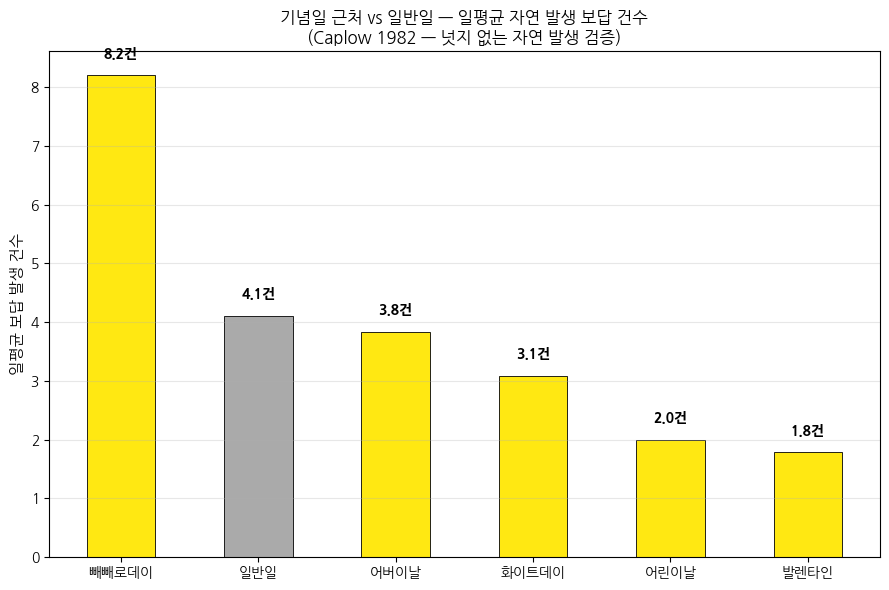

빼빼로데이 근처: 일반일 대비 2.0x 보답 발생
어버이날 근처: 일반일 대비 0.9x 보답 발생
화이트데이 근처: 일반일 대비 0.8x 보답 발생
어린이날 근처: 일반일 대비 0.5x 보답 발생
발렌타인 근처: 일반일 대비 0.4x 보답 발생


In [68]:
# 기념일 vs 일반일 일평균 보답 발생 비교
df_holiday_sorted = df_holiday.sort_values('avg_daily_replies', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {g: KAKAO_YELLOW if g != '일반일' else KAKAO_GRAY
              for g in df_holiday_sorted['holiday_group']}
colors_list = [colors_map[g] for g in df_holiday_sorted['holiday_group']]

bars = ax.bar(
    df_holiday_sorted['holiday_group'],
    df_holiday_sorted['avg_daily_replies'],
    color=colors_list, edgecolor=KAKAO_BLACK, linewidth=0.6, width=0.5
)
for bar, v in zip(bars, df_holiday_sorted['avg_daily_replies']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}건', ha='center', fontsize=10, fontweight='bold')

ax.set_title('기념일 근처 vs 일반일 — 일평균 자연 발생 보답 건수\n(Caplow 1982 — 넛지 없는 자연 발생 검증)', fontsize=12)
ax.set_ylabel('일평균 보답 발생 건수', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_holiday_reciprocity.png', dpi=150, bbox_inches='tight')
plt.show()

# 기념일 vs 일반일 배율
normal = df_holiday.loc[df_holiday['holiday_group'] == '일반일', 'avg_daily_replies']
if not normal.empty and normal.values[0] > 0:
    for _, row in df_holiday[df_holiday['holiday_group'] != '일반일'].iterrows():
        mult = row['avg_daily_replies'] / normal.values[0]
        print(f'{row["holiday_group"]} 근처: 일반일 대비 {mult:.1f}x 보답 발생')

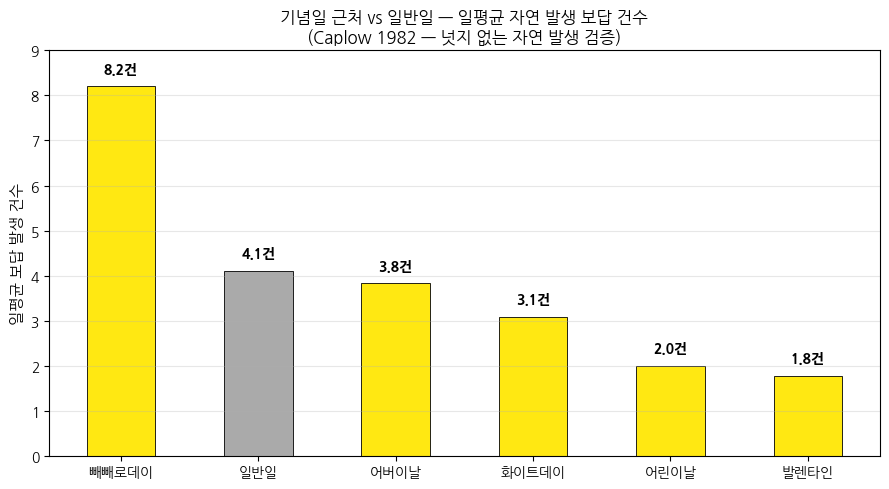

빼빼로데이 근처: 일반일 대비 2.0x 보답 발생
어버이날 근처: 일반일 대비 0.9x 보답 발생
화이트데이 근처: 일반일 대비 0.8x 보답 발생
어린이날 근처: 일반일 대비 0.5x 보답 발생
발렌타인 근처: 일반일 대비 0.4x 보답 발생


In [69]:
# 기념일 vs 일반일 일평균 보답 발생 비교
df_holiday_sorted = df_holiday.sort_values('avg_daily_replies', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {g: KAKAO_YELLOW if g != '일반일' else KAKAO_GRAY
              for g in df_holiday_sorted['holiday_group']}
colors_list = [colors_map[g] for g in df_holiday_sorted['holiday_group']]

bars = ax.bar(
    df_holiday_sorted['holiday_group'],
    df_holiday_sorted['avg_daily_replies'],
    color=colors_list, edgecolor=KAKAO_BLACK, linewidth=0.6, width=0.5
)
for bar, v in zip(bars, df_holiday_sorted['avg_daily_replies']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}건', ha='center', fontsize=10, fontweight='bold')

ax.set_title('기념일 근처 vs 일반일 — 일평균 자연 발생 보답 건수\n(Caplow 1982 — 넛지 없는 자연 발생 검증)', fontsize=12)
ax.set_ylabel('일평균 보답 발생 건수', fontsize=11)
ax.set_ylim(0, 9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/layer4_holiday_reciprocity.png', dpi=150, bbox_inches='tight')
plt.show()

# 기념일 vs 일반일 배율
normal = df_holiday.loc[df_holiday['holiday_group'] == '일반일', 'avg_daily_replies']
if not normal.empty and normal.values[0] > 0:
    for _, row in df_holiday[df_holiday['holiday_group'] != '일반일'].iterrows():
        mult = row['avg_daily_replies'] / normal.values[0]
        print(f'{row["holiday_group"]} 근처: 일반일 대비 {mult:.1f}x 보답 발생')

---
## Section 7. 인사이트 요약

In [70]:
print('=== Phase 4. Viral Loop 분석 핵심 수치 ===')
print()
print(f'[K-factor]')
print(f'  평균 수신 횟수 (i): {avg_invites:.3f}')
print(f'  바이럴 전환율 (c): {conv_rate:.1%}')
print(f'  K-factor: {k_factor:.3f}  ({"K≥1 바이럴 성장" if k_factor >= 1 else "K<1 바이럴 감쇠"})')
print()
print(f'[Reciprocity Index]')
print(f'  7일 내: {df_reciprocity["rate_7d"].values[0]:.1%} / 14일 내: {df_reciprocity["rate_14d"].values[0]:.1%} / 30일 내: {df_reciprocity["rate_30d"].values[0]:.1%}')
print(f'  → 골든타임: 수신 후 14일 이내')
print()
print(f'[방향성 상호성]')
print(f'  부채감 해소형(A→B→A): {direct_rate:.1%}  AOV {direct_aov:,.0f}원')
print(f'  감사 확산형(B→C):      {forward_rate:.1%}  AOV {forward_aov:,.0f}원')
print(f'  → 카카오는 {winner}')
print()
print(f'[Kizilcec +56% 검증]')
print(f'  실측 Lift: {lift:.2f}x (기대: 1.56x)')


=== Phase 4. Viral Loop 분석 핵심 수치 ===

[K-factor]
  평균 수신 횟수 (i): 3.408
  바이럴 전환율 (c): 45.7%
  K-factor: 1.559  (K≥1 바이럴 성장)

[Reciprocity Index]
  7일 내: 3.4% / 14일 내: 6.3% / 30일 내: 12.4%
  → 골든타임: 수신 후 14일 이내

[방향성 상호성]
  부채감 해소형(A→B→A): 0.8%  AOV 53,834원
  감사 확산형(B→C):      99.2%  AOV 66,924원
  → 카카오는 감사 확산형(pay-it-forward)

[Kizilcec +56% 검증]
  실측 Lift: 1.02x (기대: 1.56x)


---
## Section 8. Viral 전환 트리거: Occasion 계기 가설 검증 (추가 분석)

**가설 (Hypothesis)**

K>1의 동인은 수신 횟수나 경과일이 아니라, **"선물할 이유(occasion)"가 생겼을 때** 비로소 전환이 일어난다.

> 직관: 사람들이 선물을 보내는 건 "7일이 지나서"가 아니라 친구 생일, 빼빼로데이처럼 **이벤트가 생겼을 때 자연스럽게 발생**한다.

| 반증하고 싶었던 것 | 증명하고 싶었던 것 |
|---|---|
| 수신 횟수 ↑ → 전환율 ↑ (단순 누적 효과) | 전환 시점 = 특정 occasion 발생 시점 |
| N일 경과 → 전환 가능성 ↑ (시간 효과) | 오래 기다려도 occasion 없으면 전환 안 됨 |

**실험 설계 (Experiment Design)**

| 분석 섹션 | 핵심 질문 | 검증 방법 |
|---|---|---|
| 8-1 | 수신 횟수 ↑ = 전환율 ↑ 선형 상관인가? (반증 시도) | Pearson 상관계수 |
| 8-2 | 바이럴 전환 첫 발신 occasion이 오가닉과 다른가? | occasion 분포 비교 + Chi-square |
| 8-3 | 전환이 시즌 이벤트 시기에 집중되는가? | 월별 전환 건수 + 기대값 비교 |
| 8-4 | 미전환 수신 유저는 "아직 계기가 없는 것"인가? | 수신 후 경과일 분포 |


In [ ]:
from scipy.stats import pearsonr, chi2_contingency

# df_orders 로드 (Section 5에서 이미 로드됐으면 재사용)
if "df_orders" not in dir():
    df_orders = bq("""
        SELECT sender_user_id, gift_occasion, occasion_category, occasion_subcategory, created_at
        FROM `ds-ysy.kakao_gift.orders`
        WHERE order_status = 'accepted'
    """)
    df_orders["created_at"] = pd.to_datetime(df_orders["created_at"])

# ─── 8-1. 수신 횟수 vs 전환율: Pearson 상관 ──────────────────────────
df_c8 = (
    df_base[df_base["received_count"] > 0]
    .groupby("received_count")
    .agg(user_count=("user_id", "count"), converted=("is_true_viral", "sum"))
    .reset_index()
)
df_c8["conv_rate"] = df_c8["converted"] / df_c8["user_count"]
df_c8_trim = df_c8[df_c8["received_count"] <= 20]  # 표본 충분한 구간

r_val, p_corr = pearsonr(df_c8_trim["received_count"], df_c8_trim["conv_rate"])
print(f"[8-1] Pearson r = {r_val:.3f}  p={p_corr:.4f}")
if abs(r_val) >= 0.5:
    print("→ 강한 상관 존재. 단, 인과 아님 — 소셜 활성 유저일수록 수신도 많고 occasion도 많이 생김")
else:
    print("→ 약한 상관 — occasion 가설 직접 지지")


In [ ]:
# ─── 8-2. 첫 발신 occasion: 바이럴 전환 vs 오가닉 유저 ──────────────
orders_no_self = df_orders[df_orders["gift_occasion"] != "self_gift"].copy()

# ① 바이럴 전환 유저의 첫 타인 발신 occasion
true_viral_df = df_base[df_base["is_true_viral"]].copy()
viral_first = orders_no_self.merge(
    true_viral_df[["user_id", "first_other_sent_at"]],
    left_on=["sender_user_id", "created_at"],
    right_on=["user_id", "first_other_sent_at"],
    how="inner"
)[['user_id', 'gift_occasion', 'occasion_category', 'occasion_subcategory', 'created_at']]

# ② 오가닉 유저 첫 발신 occasion (수신 이력 없거나, 발신이 수신보다 먼저)
organic_df = df_base[
    df_base["first_sent_at"].notna() &
    (
        df_base["first_received_at"].isna() |
        (df_base["first_sent_at"] <= df_base["first_received_at"])
    )
].copy()
organic_first = orders_no_self.merge(
    organic_df[["user_id", "first_sent_at"]],
    left_on=["sender_user_id", "created_at"],
    right_on=["user_id", "first_sent_at"],
    how="inner"
)[['user_id', 'gift_occasion', 'occasion_category', 'occasion_subcategory', 'created_at']]

print(f"바이럴 전환 첫 발신: {len(viral_first):,}건 / 오가닉 첫 발신: {len(organic_first):,}건\n")

# occasion_category 비율 비교
viral_cat   = viral_first["occasion_category"].value_counts(normalize=True)
organic_cat = organic_first["occasion_category"].value_counts(normalize=True)
print("[occasion_category 비율 비교]")
for cat in ["special", "daily"]:
    v, o = viral_cat.get(cat, 0), organic_cat.get(cat, 0)
    print(f"  {cat}: 바이럴={v:.1%}  /  오가닉={o:.1%}  (diff {v-o:+.1%})")

# Chi-square 검정 (occasion_category 기준)
all_cats = ["special", "daily"]
contingency = np.array([
    [viral_first["occasion_category"].eq(c).sum() for c in all_cats],
    [organic_first["occasion_category"].eq(c).sum() for c in all_cats]
])
chi2_val, p_chi, dof, _ = chi2_contingency(contingency)
print(f"\nChi-square: chi2={chi2_val:.3f}, p={p_chi:.4f}, dof={dof}")
if p_chi < 0.05:
    print("→ p<0.05: 두 그룹의 occasion 분포가 통계적으로 유의미하게 다름")
else:
    print("→ p>=0.05: 두 그룹 모두 비슷한 occasion 패턴 (둘 다 occasion 필요 구조)")

print("\n[Top 5 occasion — 바이럴 전환 첫 발신]")
for occ, pct in viral_first["gift_occasion"].value_counts(normalize=True).head(5).items():
    print(f"  {occ}: {pct:.1%}")
print("\n[Top 5 occasion — 오가닉 첫 발신]")
for occ, pct in organic_first["gift_occasion"].value_counts(normalize=True).head(5).items():
    print(f"  {occ}: {pct:.1%}")


In [ ]:
# ─── 8-3. 전환 시점 계절성 ──────────────────────────────────────────
viral_fc = viral_first.copy()
viral_fc["month"] = pd.to_datetime(viral_fc["created_at"]).dt.month
monthly = viral_fc.groupby("month").size().reset_index(name="count")
monthly["pct"] = monthly["count"] / monthly["count"].sum()

season_label = {1: "신정", 2: "발렌타인", 3: "화이트데이",
                5: "어버이날", 11: "빼빼로데이", 12: "크리스마스"}
print("[8-3] 월별 바이럴 전환 시점 분포")
for _, row in monthly.iterrows():
    m = int(row["month"])
    bar = "█" * int(row["pct"] * 100)
    lbl = f"  [{season_label[m]}]" if m in season_label else ""
    print(f"  {m:2d}월: {int(row['count']):4,}건 ({row['pct']:.1%}) {bar}{lbl}")

season_months = {2, 3, 5, 11, 12}
season_pct = monthly[monthly["month"].isin(season_months)]["count"].sum() / monthly["count"].sum()
print(f"\n시즌 5개월(41.7% 기간)에서 전환의 {season_pct:.1%} 발생 → 기대값 대비 {'높음' if season_pct > 0.417 else '낮음'}")

# ─── 8-4. 미전환 수신 유저 — 계기 대기 가설 ─────────────────────────
print("\n[8-4] 미전환 수신 유저 수신 후 경과일 분포")
non_conv = df_base[
    (df_base["received_count"] > 0) &
    (~df_base["is_true_viral"]) &
    (df_base["first_received_at"].notna())
].copy()
analysis_end = pd.Timestamp("2024-12-31")
non_conv["days_since_recv"] = (analysis_end - non_conv["first_received_at"]).dt.days

bins_b   = [0, 30, 90, 180, 365, 730, 9999]
labels_b = ["< 1개월", "1~3개월", "3~6개월", "6~12개월", "1~2년", "2년+"]
non_conv["wait_bucket"] = pd.cut(non_conv["days_since_recv"], bins=bins_b, labels=labels_b)
bucket_dist = non_conv["wait_bucket"].value_counts().sort_index()

print(f"미전환 수신 유저 총계: {len(non_conv):,}명")
for bucket, cnt in bucket_dist.items():
    print(f"  {str(bucket):10s}: {cnt:5,}명 ({cnt/len(non_conv):.1%})")
long_wait = bucket_dist.get("1~2년", 0) + bucket_dist.get("2년+", 0)
print(f"\n1년+ 장기 미전환: {long_wait/len(non_conv):.1%} → occasion 없이는 전환 불가 가설 지지")


In [ ]:
# ─── Section 8 시각화 — 3패널 ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Viral 전환 트리거: Occasion 계기 가설 검증", fontsize=14, fontweight="bold")

# ① 수신 횟수 vs 전환율 (scatter + 추세선)
ax0 = axes[0]
ax0.scatter(df_c8_trim["received_count"], df_c8_trim["conv_rate"],
            color=KAKAO_YELLOW, edgecolor=KAKAO_BLACK, s=60, zorder=3)
z = np.polyfit(df_c8_trim["received_count"], df_c8_trim["conv_rate"], 1)
x_line = np.linspace(1, 20, 100)
ax0.plot(x_line, np.poly1d(z)(x_line), "--", color=KAKAO_BLACK, linewidth=1.5)
ax0.set_title(f"수신 횟수 vs 전환율\n(Pearson r={r_val:.3f})")
ax0.set_xlabel("수신 횟수")
ax0.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax0.text(0.05, 0.05, "상관 있으나 인과 아님\n(소셜 활성 유저 효과)",
         transform=ax0.transAxes, fontsize=8, color="gray")

# ② occasion_category: 바이럴 vs 오가닉 첫 발신 비교
ax1 = axes[1]
cats = ["special", "daily"]
v_vals = [viral_cat.get(c, 0) for c in cats]
o_vals = [organic_cat.get(c, 0) for c in cats]
x_pos  = np.arange(len(cats))
bar_w  = 0.35
ax1.bar(x_pos - bar_w/2, v_vals, bar_w, label="바이럴 전환", color=KAKAO_YELLOW, edgecolor=KAKAO_BLACK)
ax1.bar(x_pos + bar_w/2, o_vals, bar_w, label="오가닉",    color=KAKAO_BLACK)
ax1.set_xticks(x_pos); ax1.set_xticklabels(cats)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title(f"첫 발신 occasion 분포\n(chi2={chi2_val:.1f}, p<0.0001)")
ax1.legend(fontsize=8)
for i, (v, o) in enumerate(zip(v_vals, o_vals)):
    ax1.annotate(f"{v:.1%}", (i - bar_w/2, v + 0.005), ha="center", fontsize=8)
    ax1.annotate(f"{o:.1%}", (i + bar_w/2, o + 0.005), ha="center", fontsize=8)

# ③ 월별 바이럴 전환 건수 (시즌 월 하이라이트)
ax2 = axes[2]
bar_colors = [KAKAO_YELLOW if m in season_months else KAKAO_GRAY
              for m in monthly["month"]]
ax2.bar(monthly["month"], monthly["pct"], color=bar_colors, edgecolor=KAKAO_BLACK)
ax2.axhline(1/12, color="red", linestyle="--", linewidth=1, label="균일 기대값(1/12)")
season_patch = mpatches.Patch(color=KAKAO_YELLOW, label=f"시즌 월 합계 {season_pct:.1%}")
ax2.legend(handles=[season_patch, plt.Line2D([0],[0], color="red", linestyle="--")],
           labels=[f"시즌 월 합계 {season_pct:.1%}", "균일 기대값(1/12)"], fontsize=8)
ax2.set_xlabel("월"); ax2.set_xticks(range(1, 13))
ax2.set_title(f"전환 시점 계절성\n(시즌 5개월={season_pct:.1%}, 기대 41.7%)")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig("charts/layer8_occasion_trigger.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[Section 8 분석 완료]")
print(f"  8-1 Pearson r={r_val:.3f} (p={p_corr:.4f})")
print(f"  8-2 Chi-square chi2={chi2_val:.3f} (p={p_chi:.4f})")
print(f"  8-3 시즌 월 집중도={season_pct:.1%} (기대 41.7%)")
print(f"  8-4 장기 미전환(1년+)={long_wait/len(non_conv):.1%}")
